<a href="https://colab.research.google.com/github/vercon1/intro_data_science.1/blob/main/1_Progetto_IntroDSePC_gruppo_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto del corso - Introduzione alla Data Science e al Pensiero Computazionale - a.a. 2025/2026

# Membri del gruppo 14

Il gruppo 14 è composto da:

*   **Arianna Bertoldo:** matricola 1220440, email arianna.bertoldo@studio.unibo.it
*   **Veronica Contarin:** matricola 1233363, email veronica.contarin@studio.unibo.it


# Materiale del progetto

Il materiale del progetto è il seguente:
* Bank_Marketing.csv: il dataset contiene informazioni raccolte nel corso di attività di telemarketing svolte da un istituto bancario. Ogni record descrive un cliente e l'esito di una campagna di marketing volta a promuovere prodotti di conto deposito. L'obiettivo è quello di costruire modelli predittivi in grado di identificare i clienti che presentano una maggiore probabilità di sottoscrivere il prodotto finanziario offerto.
L'obiettivo della classificazione è prevedere se il cliente sottoscriverà un conto deposito a termine vincolato (variabile y).
* Bank_Marketing_Description: descrizione del dataset e delle variabili.

# Preparazione dell'ambiente

Prima di iniziare questa parte prepariamo l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**.

In [1]:
# Pandas
import pandas as pd
import numpy as np

# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn import svm, tree
from sklearn.metrics import *


# Fase 1

Carichiamo il dataset originale.

In [2]:
bank = pd.read_csv("Bank_Marketing.csv", sep=";")
print (bank)

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

## Input variables - bank client data:
1. age
2. job: type of job (admin., blue collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown)
3. marital: marital status (married, single, divorced) - note: "divorced" means divorced or widowed
4. education: education level (primary, secondary, tertiary, unknown)
5. default: has credit in default?
6. balance: average yearly balance, in euros
7. housing: has housing loan?
8. loan: has personal loan?
9. contact: contact communication type (unknown, cellular, telephone)
10. day: last contact day of the month
 11. month: last contact month of year
  12. duration: last contact duration, in seconds
  13. campaign: number of contacts performed during this campaign and for this client
  14. pdays: number of days that passed by after the client was last contacted from a previous campaign, -1 means client was not previously contacted
  15. previous: number of contacts performed before this campaign and for this client
  16. poutcome: outcome of the previous marketing campaign
failure, success, other, unknown
  17. y - has the client subscribed a term deposit?


## ISTRUZIONI FASE 1

Obiettivo: prima analisi del dataset per comprenderne:
* struttura;
* distribuzioni;
* qualità;
* limiti;
* possibili problemi


Requisiti - almeno:
* 8 domande/ipotesi;
* 5 statistiche descrittive;
* 3 riflessioni critiche sui dati.


Esempi:
* class imbalance;
* outlier;
* feature correlate;
* dati mancanti;
* feature sospette.

## Domanda 1.1

Informazioni generiche sul dataset *Bank_Marketing*

In [ ]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
print("Le colonne sono:", bank.shape[1]) # quante colonne
print("Le righe sono:", bank.shape[0]) # quante righe

Le colonne sono: 17
Le righe sono: 45211


In [ ]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Categorie delle variabili nominali categoriche

In [ ]:
for col in bank.select_dtypes(include='object').columns:
    print(col)
    print(bank[col].unique())
    print()

    #stampa le categorie delle variabili categoriche

job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital
['married' 'single' 'divorced']

education
['tertiary' 'secondary' 'unknown' 'primary']

default
['no' 'yes']

housing
['yes' 'no']

loan
['no' 'yes']

contact
['unknown' 'cellular' 'telephone']

month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome
['unknown' 'failure' 'other' 'success']

y
['no' 'yes']



È possibile notare che:
* la variabile '*job*' ha ben 11 varianti (escludendo i valori mancanti '*unknown*')
* la variabile '*poutcome*' (l'effetto della precedente campagna marketing) contiene una variante '*other*' di cui non conosciamo il significato




---



In [ ]:
bank[bank["duration"] > 3000]  ## questo non dovrebbe essere qui giusto?

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2386,45,blue-collar,married,secondary,no,66,yes,no,unknown,13,may,3366,3,-1,0,unknown,no
4382,34,blue-collar,married,primary,no,183,yes,no,unknown,19,may,3078,4,-1,0,unknown,no
6451,44,services,divorced,secondary,no,51,yes,yes,unknown,27,may,3094,2,-1,0,unknown,yes
9947,59,management,married,secondary,no,1321,no,no,unknown,9,jun,3881,3,-1,0,unknown,yes
12347,28,admin.,single,secondary,no,-7,no,yes,unknown,26,jun,3183,2,-1,0,unknown,yes
19639,37,blue-collar,married,tertiary,no,359,no,yes,cellular,7,aug,3422,2,-1,0,unknown,no
21113,43,self-employed,married,tertiary,no,423,no,no,cellular,14,aug,3322,2,-1,0,unknown,no
24044,36,self-employed,single,tertiary,no,-103,yes,yes,telephone,17,oct,3253,1,-1,0,unknown,yes
24095,30,admin.,married,secondary,no,1310,no,no,telephone,27,oct,3284,1,-1,0,unknown,no
24148,59,technician,married,tertiary,no,6573,yes,no,telephone,10,nov,4918,1,-1,0,unknown,no


## Domanda 1.1.2

## Quanti sono i dati mancanti?

In [ ]:
print(bank.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


Tramite questa analisi non risultano esserci dati mancanti. Tuttavia, come notato visivamente dalle prime righe del dataset, vi sono dei valori categorizzati come "unknown" e quindi di fatto mancanti.

In [3]:
unknown = (bank == "unknown").sum()

pd.DataFrame({
    "Mancanti": unknown,
    "Percentuale": (unknown / len(bank) * 100).round(1)
})

,Mancanti,Percentuale
age,0,0.0
job,288,0.6
marital,0,0.0
education,1857,4.1
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,13020,28.8
day,0,0.0


In [ ]:
bank[bank["contact"] != "unknown"].head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
12657,27,management,single,secondary,no,35,no,no,cellular,4,jul,255,1,-1,0,unknown,no
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,jul,297,1,-1,0,unknown,no
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,jul,668,2,-1,0,unknown,no
12660,31,technician,single,secondary,no,19,no,no,telephone,4,jul,65,2,-1,0,unknown,no
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,jul,436,4,-1,0,unknown,no


'*contact*' assume un valore diverso da '*unknown*' solo a partire dalla riga 12.657, nel mese di luglio.

Notiamo che la maggioranza delle variabili **non** presenta valori mancanti, tuttavia:
* **i dati sui contatti dei clienti sono incompleti**, dal momento che vengono registrati solo a partire dal mese di luglio
* la variabile '*poutcome*', cioè **l'esito della precedente campagna pubblicitaria, è sconosciuto circa nell'80% dei casi**
* istruzione e lavoro presentano basse percentuali di dati mancanti, probabilmente non dichiarati dai clienti stessi

In [ ]:
nuovi = (bank['previous'] == 0).sum()
nuovi_perc = (nuovi/len(bank)*100).round(2)
print("I clienti che non erano mai stati contattati prima sono", nuovi,".")
print("L'", nuovi_perc, "%", "del totale.")


I clienti che non erano mai stati contattati prima sono 36954 .
L' 81.74 % del totale.


Questo spiega la ragione dei dati mancanti nel caso di '*poutcome*', che descrive l'esito della campagna marketing precedente.





##Domanda xx (1.3)

##I cliente già contattati compaiono più volte nel dataset?



In [4]:
#idea nostra, codice ai

cols = [
    'age', 'job', 'marital', 'education',
    'default', 'balance', 'housing', 'loan'
]

duplicati = bank[bank.duplicated(subset=cols, keep=False)]
#un duplicato è una riga che ha cols uguali
#mantiene solo le righe duplicate


duplicati.sort_values(cols)
#ordina le colonne di modo che i valori identici
#a partire dalla colonna age siano conseguenti

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
40887,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
42274,18,student,single,primary,no,608,no,no,cellular,13,nov,210,1,93,1,success,yes
40744,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
41487,18,student,single,unknown,no,108,no,no,cellular,8,sep,169,1,-1,0,unknown,yes
42954,18,student,single,unknown,no,108,no,no,cellular,9,feb,92,1,183,1,success,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45010,86,retired,married,primary,no,1255,no,no,cellular,14,oct,192,2,92,4,success,no
41934,92,retired,married,unknown,no,775,no,no,cellular,22,oct,313,3,-1,0,unknown,yes
42727,92,retired,married,unknown,no,775,no,no,cellular,26,jan,164,4,96,3,success,yes
44262,93,retired,married,unknown,no,775,no,no,cellular,22,jul,860,2,177,7,success,yes


In [ ]:
duplicates = bank.duplicated().sum()
print(duplicates)

0


Sì, i clienti contattati più volte compaiono come righe diverse nel dataset:


* tuttavia **non si tratta di duplicati identici**, ma **differiscono** nelle variabili successive a 'duration'
* forniscono informazioni utili e non costituiscono un punto di debolezza del dataset, ma una risorsa informativa aggiuntiva


## Domanda xx (1.4)

##Qual è la condizione socio-economica del campione?

In [5]:
(bank['job'].value_counts(normalize=True) * 100).round(2)

,proportion
job,
blue-collar,21.53
management,20.92
technician,16.80
admin.,11.44
services,9.19
retired,5.01
self-employed,3.49
entrepreneur,3.29
unemployed,2.88


In [6]:
bank.groupby('job')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


#named aggregation, richiama le funzioni sotto forma di stringhe

,media,mediana,dev_standard,minimo,massimo
job,,,,,
retired,1984.22,787.0,4397.04,-1598,81204
unknown,1772.36,677.0,2970.29,-295,19706
management,1763.62,572.0,3822.97,-6847,102127
unemployed,1521.75,529.0,3144.67,-1270,44134
self-employed,1647.97,526.0,3684.26,-3313,52587
student,1388.06,502.0,2441.70,-679,24025
technician,1252.63,421.0,2548.54,-2827,45248
housemaid,1392.40,406.0,2984.69,-1941,45141
admin.,1135.84,396.0,2641.96,-1601,64343


Le categorie lavorative più rappresentate, manager e operai, sono, com'è prevedibile, ai poli opposti della distribuzione.

In [7]:
(bank['marital'].value_counts(normalize=True) * 100).round(2)

,proportion
marital,
married,60.19
single,28.29
divorced,11.52


In [8]:
bank.groupby('marital')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


,media,mediana,dev_standard,minimo,massimo
marital,,,,,
married,1425.93,477.0,3140.96,-6847,98417
single,1301.50,437.0,2875.32,-8019,102127
divorced,1178.87,348.0,2926.45,-4057,66721


In [9]:
bank['age_category'] = pd.cut(
    bank['age'],
    bins=[0, 30, 60, float('inf')],
    labels=['Under 30', '30-59', 'Over 60'],
    right=False #nell'intervallo è escluso il valore a destra
)

totali = bank['age_category'].value_counts()
frequenze = ((totali/len(bank))*100).round(2)


pd.DataFrame({
    'totali': totali,
    'percentuali': frequenze
})

,totali,percentuali
age_category,,
30-59,38154,84.39
Under 30,5273,11.66
Over 60,1784,3.95


In [10]:
bank.groupby('age_category')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


/tmp/ipykernel_460/3431944438.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bank.groupby('age_category')['balance'].agg(


,media,mediana,dev_standard,minimo,massimo
age_category,,,,,
Over 60,2458.62,1058.0,5071.70,-4057,81204
30-59,1362.93,449.5,3010.89,-6847,102127
Under 30,986.57,339.0,2155.62,-8019,36252


Notiamo che:
* le **categorie lavorative** più rappresentate sono gli *operai* (21,5%), i *manager* (20,9%) e i *tecnici* (16%), che insieme costituiscono poco più della metà della clientela totale (del campione)
* la **fascia d'età** più rappresentata è quella *intermedia*: chi ha fra i 30 e i 59 anni compone l'84% del campione. I giovani costituiscono l'11,6% e gli anziani sono fortemente sottorappresentati (3,9%)
* per lo **stato civile**, la maggioranza dei clienti nel campione sono sposati (60%), una buona parte sono single (28%) e il restante divorziati o vedovi (11,5%).

**

Analizzando **la distribuzione della giacenza media annua** (variabile che ci fornisce un'idea della loro condizione economica e predisposizione ad usufruire di servizi bancari) in relazione a queste tre variabili ('*job*', '*age*', '*marital*') notiamo che:

* I **pensionati** costituiscono in media la categoria più "ricca", ma anche la più variabile: è probabile che ci siano molti casi che presentano valori molto più alti della media. Tuttavia sono solo una minima parte del campione, attorno al 5%.
* Anche gli **imprenditori** presentano un'altissima variabilità al loro interno, ma anche loro sono pochi rispetto all'insieme (3,3%)

→ potrebbe essere utile studiarne in seguito la distribuzione, per verificare la presenza di *outlier*

* I più "poveri" sono i **lavoratori nei servizi** (circa il 9% del campione), con un valore mediano della giacenza intorno ai 340 euro, contro i 787 dei pensionati, e con meno variabilità rispetto alla media (poco meno di 1000 euro).

Per ciò che riguarda lo stato civile:

* Tendenzialmente i divorziati sono più poveri (e la minor parte del campione, circa l'11%), mentre gli **sposati** più ricchi (~60% del totale).

Mentre per l'età:

* Gli **over 60** (~4% del campione) presentano la giacenza media più alta fra tutte le categorie considerate (media di 2458 euro annui), ma una fortissima variabilità al suo interno.

* La categoria di mezza età (~84% del totale) si colloca a livello intermedio, fra anziani tendenzialmente molto più "ricchi" e giovani più "poveri".






## Domanda 1.5

Quanti clienti hanno sottoscritto un conto deposito in questa campagna? E nella precedente?

In [11]:
print("Aderenti al conto deposito:", round(len(bank[bank["y"] == "yes"]) / len(bank)*100, 2), "%")

Aderenti al conto deposito: 11.7 %


La percentuale di adesione è piuttosto bassa: circa 1 persona su 10 sottoscrive il conto deposito proposto.

In [12]:
print("Aderenti al conto deposito nella campagna precedente:", round(len(bank[bank["poutcome"] == "success"]) / len(bank)*100, 2), "%")

Aderenti al conto deposito nella campagna precedente: 3.34 %


## DOMANDA XX

## La condizione socio-economica ha influenzato l'adesione ad un conto deposito?

In [13]:
ct = pd.crosstab(index = bank['job'], columns = bank['y'], normalize = "index").round(3)*100
ct_job = ct.sort_values(by='yes', ascending=False)
ct_job

y,no,yes
job,,
student,71.3,28.7
retired,77.2,22.8
unemployed,84.5,15.5
management,86.2,13.8
admin.,87.8,12.2
unknown,88.2,11.8
self-employed,88.2,11.8
technician,88.9,11.1
services,91.1,8.9


* Gli **studenti** sono stati i più propensi ad iscriversi ad un conto deposito (quasi il 29% lo è); seguono pensionati, disoccupati, manager e amministrativi.

* I meno inclini in assoluto sono stati gli **operai** (il 7%), seguiti da imprenditori, casalinghi e lavoratori nei servizi.




In [14]:
ct = pd.crosstab(index = bank['marital'], columns = bank['y'], normalize = "index").round(3)*100
ct_marital = ct.sort_values(by='yes', ascending=False)
ct_marital

y,no,yes
marital,,
single,85.1,14.9
divorced,88.1,11.9
married,89.9,10.1


* Le differenze fra gruppi sono di pochi punti percentuale (al massimo 5%), comunque sembra che i **single** siano stati i più inclini ad aprire un conto deposito, mentre gli **sposati** i meno.

In [15]:
ct = pd.crosstab(index = bank['age_category'], columns = bank['y'], normalize = "index").round(3)*100
ct_age = ct.sort_values(by='yes', ascending=False)
ct_age

y,no,yes
age_category,,
Over 60,66.4,33.6
Under 30,82.4,17.6
30-59,90.1,9.9


Qui le differenze sono rilevanti:

* gli **over 60** hanno aperto con molta frequenza un conto deposito (il 33,6% di loro lo ha fatto)
* invece, solo il 10% della fascia di **mezza età** lo ha fatto

## Domanda 1.7?

Ci sono delle relazioni tra l'avere prestiti (mutuo o prestito personale) e l'insolvenza?

In [16]:

round(pd.crosstab(index=[bank["loan"], bank["housing"]], columns = bank["default"], normalize = "index"), 4)*100

default          no   yes
loan housing             
no   no       98.77  1.23
     yes      98.55  1.45
yes  no       94.16  5.84
     yes      96.95  3.05

Si nota una maggiore tendenza all'insolvenza tra i clienti che hanno contratto dei prestiti, in particolare tra coloro che hanno contratto prestiti personali, rispetto a un mutuo per l'acquisto di una casa.

## Domanda 1.8?

Come sono stati contattati i clienti? C'è una correlazione con l'età? Ipotizziamo che le persone più anziane siano state contatte più spesso tramite telefono fisso.

In [17]:
contact_assoluto = bank['contact'].value_counts()
contact_perc = bank['contact'].value_counts(normalize=bool).round(4)*100

pd.DataFrame({
    'totali': contact_assoluto,
    'percentuali': contact_perc
})

,totali,percentuali
contact,,
cellular,29285,64.77
unknown,13020,28.80
telephone,2906,6.43


Il 64,8% dei clienti è stato contattato tramite cellulare, e solo il 6,4% via telefono fisso. D'altro canto, quasi il 29% delle osservazioni in questo campo è mancante. Non è infatti stato registrato questo dato per i primi mesi. Ulteriormente, vi sono alcuni dati mancanti anche in seguito.

In [ ]:
bank.groupby(bank["contact"])["age"].mean()

,age
contact,
cellular,40.400785
telephone,47.837922
unknown,40.600077


L'età media di chi è stato contattato tramite mezzo ignoto corrisponde con l'età media dei clienti nel dataset. Quella del 'cellular' è solo marginalmente sotto alla media. Dall'altro lato, i clienti contattati tramite telefono fisso hanno un età media decisamente più alta della media del dataset.

In [ ]:
pd.crosstab(index = bank["age_category"], columns = bank["contact"], normalize = "index").round(4)*100

contact,cellular,telephone,unknown
age_category,,,
Under 30,66.51,4.63,28.86
30-59,64.55,5.81,29.64
Over 60,64.35,24.94,10.71


L'ipotesi è confermata. I clienti più anziani (Over 60) sono stati contattati via telefono fisso (telephone) con una frequenza significativamente maggiore (24.94%) rispetto alle altre fasce d'età. Inoltre, la percentuale di contatti unknown è molto inferiore per gli Over 60 (10.71%). Una possibile spiegazione è che siano stati chiamati soprattutto dopo luglio, quindi una volta iniziato a raccogliere il dato.


In [ ]:
unknowncontact = bank[bank["contact"] == "unknown"]
unknowncontact["age"].describe()

,age
count,13020.000000
mean,40.600077
std,9.439221
min,20.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,61.000000


In [ ]:
contact_until_july7 = bank.iloc[0:12657]
contact_until_july7["age"].describe()

,age
count,12657.000000
mean,40.677017
std,9.409181
min,20.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,61.000000


In [ ]:
print("Il", round(len (contact_until_july7) / len(unknowncontact), 4)*100, "% dei contatti mancanti risale al periodo fino al 7 luglio.")

Il 97.21 % dei contatti mancanti risale al periodo fino al 7 luglio.


Considerando che la maggior parte dei contatti mancanti è relativo al periodo precedente al 7 luglio, riteniamo rilevante analizzare questo periodo. I dati sui contanti mancanti in seguito potrebbero essere degli errori o essere invece assenze significative.

In [ ]:
print("Over 60 prima del 7 luglio:", len(contact_until_july7[contact_until_july7["age"] >= 60]))
print("Over 60 prima del 7 luglio (percentuale):", round(len(contact_until_july7[contact_until_july7["age"] >= 60]) / len(contact_until_july7)*100,2))

Over 60 prima del 7 luglio: 186
Over 60 prima del 7 luglio (percentuale): 1.47


In [ ]:
print("Over 60 totali:", len(bank[bank["age"] >= 60]))
print("Over 60 totali (percentuale):", round(len(bank[bank["age"] >= 60]) / len(bank)*100, 2))

Over 60 totali: 1784
Over 60 totali (percentuale): 3.95


Effettivamente, nonostante media e mediana dell'età delle osservazioni in cui il tipo di contatto è mancante corrispondano quasi esattamente a età media e mediana dell'intero dataset (rispettivamente 40.93 e 39.0), l'età massima delle persone contattate nei primi mesi è di 61 anni. Gli individui con almeno 60 anni sono evidentemente sottorappresentati nelle osservazioni dei primi mesi.

## Domanda 1.9?

C'è una relazione tra livello di istruzione e insolvenza? E tra livello di istruzione e adesione al conto deposito?

L'ipotesi è che persone con un livello di istruzione più elevato possano avere situazioni economiche più stabili e/o una più oculata gestione delle finanze e dei debiti. In virtù di ciò, ci aspettiamo che potrebbero essere più bendisposte a mettere i loro risparmi in un conto deposito.

In [18]:
round(pd.crosstab(index= bank["education"], columns = bank["default"], normalize = "index"), 4)*100

default,no,yes
education,,
primary,98.15,1.85
secondary,98.03,1.97
tertiary,98.51,1.49
unknown,98.28,1.72


Non c'è una relazione significativa tra il livello di istruzione e l'insolvenza

In [ ]:
round(pd.crosstab(index= bank["education"], columns = bank["y"], normalize = "index"), 4)*100

y,no,yes
education,,
primary,91.37,8.63
secondary,89.44,10.56
tertiary,84.99,15.01
unknown,86.43,13.57


Esiste una correlazione, seppur non enorme, tra istruzione e la sottoscrizione di un conto deposito. I clienti con istruzione terziaria mostrano la più alta propensione a sottoscrivere (15.01%), mentre quelli con istruzione primaria hanno la più bassa (8.63%).


## Domanda 1.10?

Un successo nella campagna precedente comporta maggiori probabilità di successo nella campagna attuale?

Vi è una correlazione tra l'esito della campagna e il numero di contatti effettuati?

In [ ]:
poutcome_vs_y = pd.crosstab(bank["poutcome"], bank["y"], normalize="index").mul(100).round(2) #mul = multiplication
display(poutcome_vs_y)

y,no,yes
poutcome,,
failure,87.39,12.61
other,83.32,16.68
success,35.27,64.73
unknown,90.84,9.16


Un successo nella campagna precedente è correlato con una percentuale di sottoscrizioni molto più alta nella campagna attuale rispetto alle altre categorie. Anche 'other' (outcome ignoto) ha una percentuale di successo superiore alla media. 'failure' e 'unknown' hanno invece percentuali di successo basse, simili alla media generale di 11.7%

Il numero di volte in cui un cliente è stato contattato nelle campagne precedenti influenza la sua propensione a sottoscrivere un conto deposito nell'attuale campagna?

In [ ]:
previous_vs_y = pd.crosstab(bank['previous'], bank['y'], normalize='index').mul(100).round(2)
display(previous_vs_y)

y,no,yes
previous,,
0,90.84,9.16
1,78.97,21.03
2,78.35,21.65
3,74.26,25.74
4,76.05,23.95
5,73.64,26.36
6,70.04,29.96
7,73.66,26.34
8,69.77,30.23


Notiamo che i clienti con da 1 a 14 contatti precedenti hanno una percentuale di successo più alta del doppio rispetto a chi non è mai stato contattato.

Un'ipotesi è che i clienti mai contattati in precedenza sono nuovi clienti con un grado di fidelizzazione e fiducia nell'ente ancora basso. Si potrebbe anche trattare di clienti molto giovani, che hanno appena aperto il loro primo conto in banca, che non hanno ancora una somma di risparmi tale da rendere ragionevole l'adesione a un conto deposito.

Oltre i 14 contatti, i clienti che sottoscrivono il conto deposito sono sparuti. Da un lato, sono una minoranza i clienti che vengono contattati così tante volte. Dall'altro, ciò potrebbe suggerire un effetto di 'stanchezza' e persistente disinteresse da parte di quei clienti erano già poco interessati.

In [ ]:
campaign_vs_y = pd.crosstab(bank['campaign'], bank['y'], normalize='index').mul(100).round(2)
display(campaign_vs_y)

y,no,yes
campaign,,
1,85.40,14.60
2,88.80,11.20
3,88.81,11.19
4,91.00,9.00
5,92.12,7.88
6,92.87,7.13
7,93.61,6.39
8,94.07,5.93
9,93.58,6.42


Per quanto riguarda la campagna attuale, la probabilità di successo è al picco con 1 solo contatto (14.60%) e diminuisce rapidamente all'aumentare dei contatti nella stessa campagna. Per più di 3-4 contatti, la percentuale di successo cala drasticamente e, in molti casi, diventa 0 per un numero elevato di contatti.

Va notato, a questo proposito, che chi è subito interessato sarà chiamato solo una volta. Quindi coloro che ricevono più contatti sono i meno interessati e più difficili da convincere. Per alcuni il tempo trascorso tra un contatto e l'altro potrebbe agire da stimolo, mentre molti altri potrebbero essere irremovibili.

Questo evidenzia un rendimento decrescente per il numero di contatti all'interno della stessa campagna.

In [ ]:
pd.crosstab(bank["y"], bank["pdays"], normalize="index", margins=True) # di difficile lettura e poca rilevanza

pdays,-1,1,2,3,4,5,6,7,8,9,...,805,808,826,828,831,838,842,850,854,871
y,,,,,,,,,,,,,,,,,,,,,
no,0.840890,0.000225,0.000877,0.000025,0.000025,0.000276,0.000225,0.000175,0.000626,0.000225,...,0.000000,0.000025,0.000025,0.000000,0.000025,0.000025,0.000000,0.000025,0.000000,0.000025
yes,0.639818,0.001134,0.000378,0.000000,0.000189,0.000000,0.000189,0.000000,0.000000,0.000567,...,0.000189,0.000000,0.000000,0.000189,0.000000,0.000000,0.000189,0.000000,0.000189,0.000000
All,0.817367,0.000332,0.000818,0.000022,0.000044,0.000243,0.000221,0.000155,0.000553,0.000265,...,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022


Ricapitolando:

*  Esiste una forte analogia: un esito positivo nella campagna precedente aumenta notevolmente la probabilità di una sottoscrizione nella campagna attuale. Allo stesso modo, un numero moderato (da 1 a 14) di precedenti contatti è associato a una maggiore probabilità di successo rispetto a nessun contatto precedente.
* Per i numeri di contatto di entrambe le campagne (previous e campaign) si osserva un punto di massima intorno alle prime chiamate a cui segue un rendimento decrescente. Troppi contatti tendono a ridurre, o almeno non aumentare, la probabilità di sottoscrizione. Un'eccessiva insistenza non si rivela efficace o produttiva.

## Domanda xx

## L'esito della precedente campagna influenza il successo di quella attuale?

In [ ]:
pd.crosstab(
    bank['previous'] == 0,
    bank['y'],
    normalize='index'
).round(3) * 100

y,no,yes
previous,,
False,76.9,23.1
True,90.8,9.2


I clienti che non erano mai stati contattati prima sono molto restii ad aderire al conto deposito offerto (**solo il 9,2% vi ha aderito**).
I clienti già contattati in altre campagne, invece, sono più propensi ad aprirne uno (il 23% di loro lo ha fatto).


In [ ]:
pd.crosstab(
    bank['previous'] > 0,
    bank['poutcome'],
    normalize='index'
).round(3) * 100

poutcome,failure,other,success,unknown
previous,,,,
False,0.0,0.0,0.0,100.0
True,59.4,22.3,18.3,0.1


Gli **esiti delle campagne marketing precedenti** hanno, nel complesso, avuto un tasso di insuccesso quasi del 60%.

Non sapendo a cosa si riferisca la categoria 'other', consideriamo un tasso di successo del 18%.


In [ ]:
pd.crosstab(
    bank['poutcome'],
    bank['y'],
    normalize='index'
).round(3) * 100

y,no,yes
poutcome,,
failure,87.4,12.6
other,83.3,16.7
success,35.3,64.7
unknown,90.8,9.2


Analizzando la relazione tra **esito della campagna precedente** e **apertura di un conto deposito** emerge che:

* i clienti che hanno risposto positivamente alla campagna precedente hanno sottoscritto più spesso un conto deposito (quasi il **65%**)
* quando invece la campagna precedente è risultata fallimentare, spesso nemmeno quella attuale per i conti deposito ha avuto successo (l'87% dei clienti non ha aperto un conto deposito in seguito)

**RIFLESSIONE**

Dall'analisi svolta la risposta positiva alla precedente campagna marketing della banca sembrerebbe un fattore rilevante per prevedere l'esito di quella attuale.

I clienti che hanno già aderito a proposte avanzate dalla propria banca potrebbero essere più fiduciosi nei servizi loro proposti.

D'altra parte, come abbiamo già osservato, il tasso di adesione all'offerta del conto deposito, per il campione in analisi, è abbastanza basso (11,7%).

Sapendo che la maggioranza dei clienti nel campione non erano mai stati contattati prima (più dell'80%) e visto il loro basso tasso di adesione (poco più del 9%), questo potrebbe spiegare il trend negativo della campagna attuale.

## Domanda 1.11

Durata chiamate

In [ ]:
bank["duration"].describe()

,duration
count,45211.000000
mean,258.163080
std,257.527812
min,0.000000
25%,103.000000
50%,180.000000
75%,319.000000
max,4918.000000


Una chiamata dura in media 258 secondi, ossia 4 minuti e 18 secondi. La mediana è di 180 secondi (3 minuti). Ciò suggerisce che alcune chiamate molto lunghe, possibilmente outliers, influenzino la media.
Si nota che la chiamata massima, 4918 secondi ossia quasi 82 minuti, appare irrealistica e plausibilmente un errore.

In [29]:
# Calculate IQR
Q1 = bank['duration'].quantile(0.25)
Q3 = bank['duration'].quantile(0.75)
IQR = Q3 - Q1
# Filter out outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_bank = bank[(bank['duration'] >= lower_bound) & (bank['duration'] <= upper_bound)]

In [ ]:
filtered_bank["duration"].describe()

,duration
count,41976.000000
mean,203.490947
std,140.805074
min,0.000000
25%,98.000000
50%,167.000000
75%,277.000000
max,643.000000


Rimuovendo gli outliers, vediamo che la media si è abbassata di quasi un minuto, assestandosi sui 203 secondi (3 minuti e 23 secondi) e la mediana è di 167 secondi (2 minuti e 47 secondi).
La chiamata massima di 643 secondi, corrispondente a quasi 11 minuti, risulta realistica.

Esaminiamo inoltre se c'è una relazione tra la durata delle chiamate e l'esito della campagna attuale.

In [ ]:
duration_by_y = bank.groupby('y')['duration'].describe().round(2)
display(duration_by_y)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.18,207.38,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.29,392.53,8.0,244.0,426.0,725.0,3881.0


Le chiamate che portano a una sottoscrizione hanno una durata media e mediana considerevolmente più alta rispetto alle chiamate che non hanno successo. La durata media per 'yes' è di oltre 530 secondi (quasi 9 minuti), mentre per 'no' è di circa 220 secondi (meno di 4 minuti).

Ragionevolmente, un cliente non interessato non vorrà soffermarsi più del dovuto, mentre un cliente incuriosito potrebbe avere delle domande da porre, portando quindi a una chiamata più lunga.

Comunque, tutto ciò supporta l'idea che un contatto più lungo sia associato a un maggiore successo.

In [ ]:
bins = [0, 60, 120, 180, 240, 300, 420, 600, 900, float('inf')]
labels = ['0-60s', '61-120s', '121-180s', '181-240s', '241-300s', '301-420s', '421-600s', '601-900s', '>900s']

bank['duration_bin'] = pd.cut(bank['duration'], bins=bins, labels=labels, right=True, include_lowest=True)

duration_bin_success = pd.crosstab(bank['duration_bin'], bank['y'], normalize='index').mul(100).round(2)
display(duration_bin_success)

y,no,yes
duration_bin,,
0-60s,99.81,0.19
61-120s,97.82,2.18
121-180s,94.22,5.78
181-240s,90.34,9.66
241-300s,87.30,12.70
301-420s,84.31,15.69
421-600s,75.80,24.20
601-900s,58.14,41.86
>900s,40.76,59.24


Suddividendo la durata delle chiamate in fasce (per ogni minuto in più e poi maggiori) possiamo avere una visione più dettagliata.

Emerge che la percentuale di successo aumenta drasticamente con l'aumentare della durata della chiamata. Le chiamate entro un minuto hanno una percentuale di sucesso minima (0.19%) e sono quindi tendenzialmente dei 'no' secchi, o per mancanza di interesse o per il disturbo posto dalla chiamata.

Chiamate oltre i 300 secondi (5 minuti), mostrano percentuali di sottoscrizione elevate, arrivando quasi al 60% per durate superiori ai 600 secondi (10 minuti).

Queste evidenze confermano e rafforzano l'osservazione precedente: chiamate più lunghe sono fortemente associate a sottoscrizioni riuscite.

### CORRELAZIONE TRA DURATA E ESITO CAMPAGNA

In [24]:
# @title Deve restare da qualche parte perché lo uso in un grafico
bank['y_numeric'] = bank['y'].map({'no': 0, 'yes': 1})

In [ ]:
spearman_y_dur = bank["y_numeric"].corr(bank["duration"], method="spearman")
print(spearman_y_dur)

0.34246867107659157


In [ ]:
pearson_y_dur = bank["y_numeric"].corr(bank["duration"], method="pearson")
print(pearson_y_dur)

0.39452101589456207


# DOPO QUANTI GIORNI E QUANTE VOLTE CHIAMARE I POTENZIALI CLIENTI?

pdays, campaign --> y

<Axes: xlabel='pdays', ylabel='campaign'>

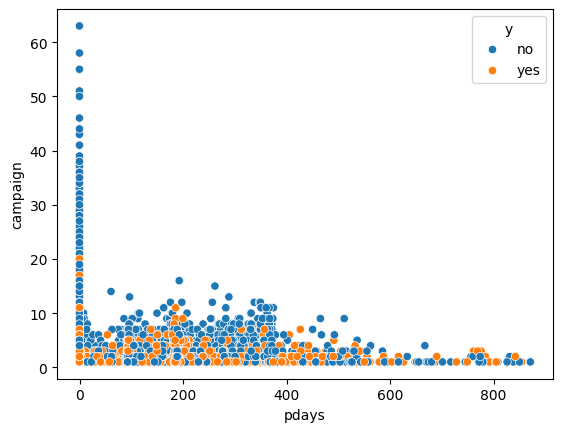

In [ ]:
sns.scatterplot(x="pdays", y="campaign", hue="y", data=bank)

<Axes: xlabel='pdays', ylabel='campaign'>

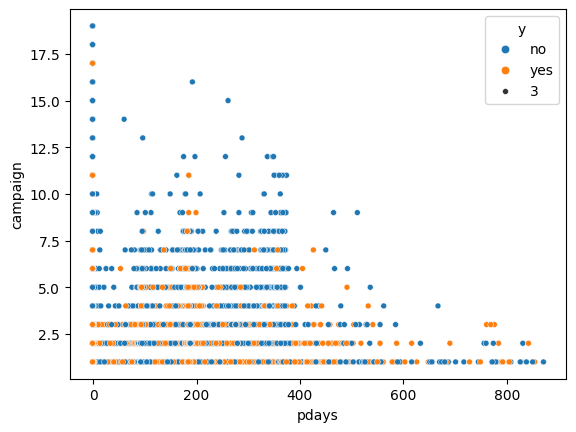

In [ ]:
campaignbasso = bank[bank["campaign"] < 20]
sns.scatterplot(x="pdays", y="campaign", hue="y", data=campaignbasso, size=3)

# Fase 2

Obiettivo: capire (e comunicare) relazioni tra feature - fra di loro, ed in particolare rispetto al target.

Requisiti - almeno:
* 4 grafici diversi;
* 4 domande/ipotesi;
* 2 confronti tra variabili/gruppi/classi.

Cercate di usare gli strumenti che abbiamo affrontato (scatterplot, boxplot,
heatmap, barplot, ecc.).

Opzionalmente: guardate le gallerie di grafici forniti dalla libreria seaborn (es. [1]) e valutate di introdurre alcuni di questi se utile.
[1]
https://seaborn.pydata.org/examples/index.html


IDEE
* A - un maxi grafico per previous, poutcome, campaign e duration vs y (see ciao). O dei grafici vicini comunque
* A - differenze per età per balance e per contact (box plot) e magari altro ?

* V - distribuzione balance ed età. grafici specifici per i lavori (studio outlier). distribuzione età e y. distribuzione job e y.
* V - qualcosa su loan housing e default e y?

Grafico per giacenza media e tipo di contatto, con la sottoscrizione del conto deposito.

<Axes: xlabel='contact', ylabel='balance'>

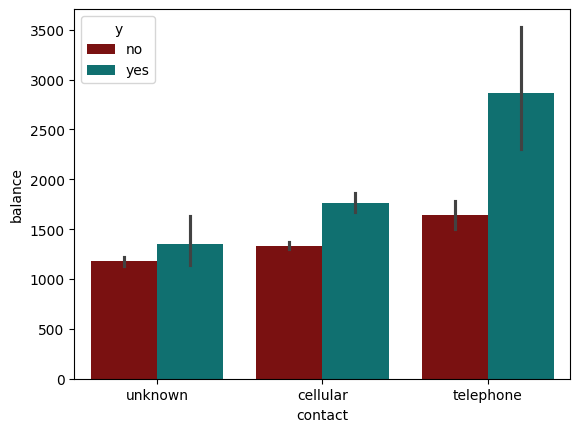

In [ ]:
sns.barplot(x="contact", y="balance", hue="y",  data=bank, palette = {"no":"darkred", "yes": "teal"})

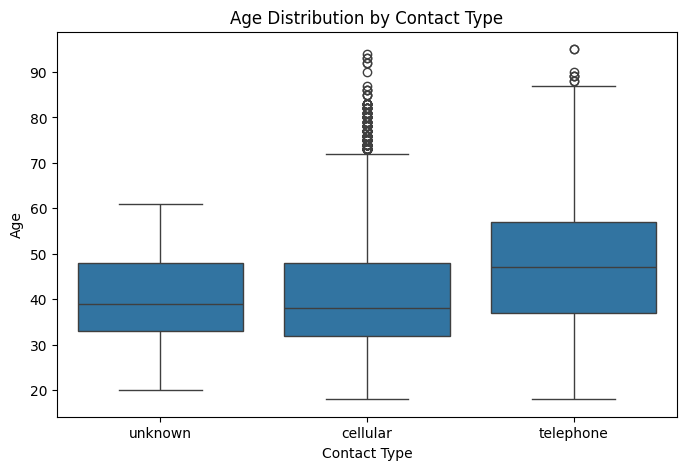

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='contact', y='age', data=bank)
plt.title('Age Distribution by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Age')
plt.show()

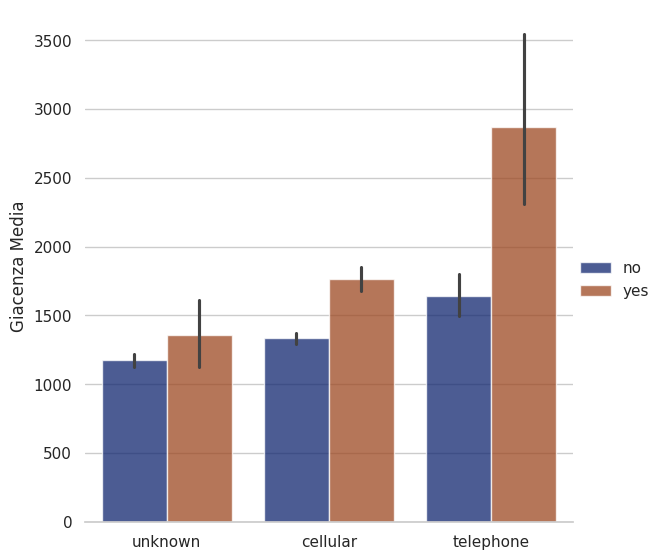

In [34]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=bank, kind="bar",
    x="contact", y="balance", hue="y", palette="dark", alpha=.75, height=6
)
g.despine(left=True)
g.set_axis_labels("", "Giacenza Media")
g.legend.set_title("")

<Axes: xlabel='age', ylabel='balance'>

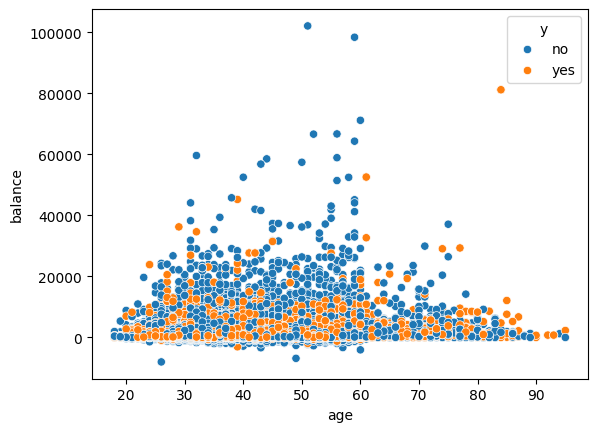

In [ ]:
sns.scatterplot(x="age", y="balance", hue="y", data=bank)

## Domanda 2.1?
GIACENZA MEDIA PER CONDIZIONE LAVORATIVA

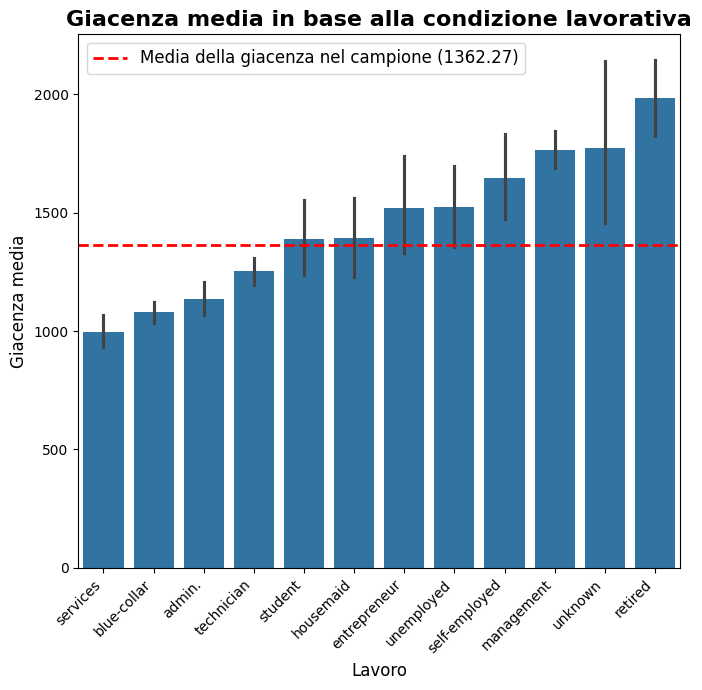

media giacenza nel campione 1362.27
mediana 448.0


In [ ]:

ordine_lavori = bank.groupby('job')['balance'].mean().sort_values().index
#così sono ordinati in base alla media di balance

balance_mean = bank['balance'].mean()
balance_median = bank['balance'].median()

plt.figure(figsize=(7, 7))
sns.barplot(data=bank, x='job', y='balance', order=ordine_lavori)
plt.axhline(y=balance_mean,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Media della giacenza nel campione ({balance_mean:.2f})')
plt.title("Giacenza media in base alla condizione lavorativa", fontsize=16, fontweight='bold')
plt.xlabel("Lavoro", fontsize=12)
plt.ylabel("Giacenza media", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

print("media giacenza nel campione", balance_mean.round(2))
print("mediana", balance_median)

## Domanda 2.2?

Come varia il successo della campagna marketing a seconda del numero di contatti effettuati e secondo l'esito della campagna precedente?

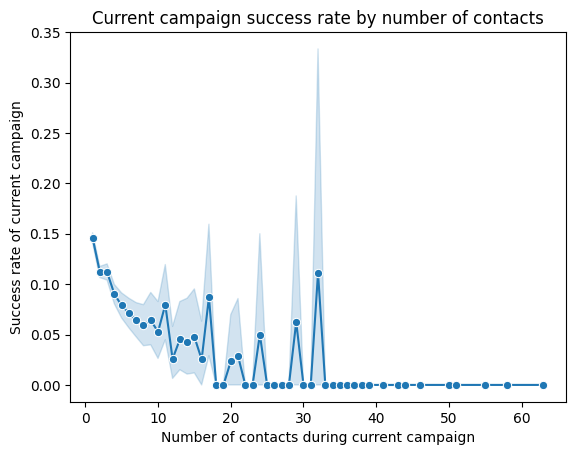

In [25]:
sns.lineplot(data=bank, x="campaign", y="y_numeric", marker="o", errorbar=("ci", 95))
#Media di y_numeric indica il success rate
plt.xlabel("Number of contacts during current campaign")
plt.ylabel("Success rate of current campaign")
plt.title("Current campaign success rate by number of contacts")
plt.show()

Il tasso di successo risulta massimo per i primi 1-3 contatti. Come già evidenziato dai dati in precedenza, possiamo vedere come un maggior numero di contatti nell'attuale campagna è associato a un successo decrescente. In particolare, oltre i 35 contatti circa, il tasso di successo è pari a 0.

Contatti ripetuti non aumentano dunque il tasso di successo. Al contrario, un numero elevato di contatti potrebbe indicare che si tratta di clienti più difficili da convincere.

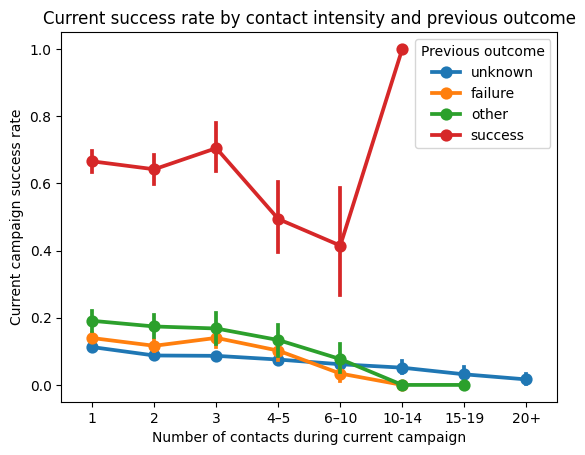

In [26]:
bank["campaign_group"] = pd.cut(
    bank["campaign"],
    bins=[0, 1, 2, 3, 5, 10, 15, 20, bank["campaign"].max()],
    labels=["1", "2", "3", "4–5", "6–10", "10-14", "15-19", "20+"]
)
# li unisco perché success aveva dei valori estremi e non era ben leggibile

sns.pointplot(data=bank, x="campaign_group", y="y_numeric", hue="poutcome", errorbar=("ci", 95))

plt.xlabel("Number of contacts during current campaign")
plt.ylabel("Current campaign success rate")
plt.title("Current success rate by contact intensity and previous outcome")
plt.legend(title = "Previous outcome")
plt.show()

Differenziando i clienti in base all'esito della precedente campagna marketing, notiamo delle notevoli differenze sia nell'efficacia dei contatti che nel tasso di successo.

I clienti che già hanno sottoscritto un conto deposito hanno tassi di successo molto più alti rispetto agli altri gruppi. Il precedente successo è un forte predittivo per il successo nella campagna attuale.

Invece, clienti con precedenti esiti negativi, diversi o ignoti mostrano un tasso di successo molto più basso. Inoltre, tra questi gruppi, il tasso di successo diminuisce con l'aumentare del numero dei contatti.

Nota: il tasso di successo tra i clienti che hanno già sottoscritto un conto deposito in precedenza arriva al 100% con un numero di contatti tra 10 e 14. Plausibilmente, si tratta di un campione di clienti molto ridotto.

Tutto sommato, sembra più efficace indirizzare gli sforzi verso clienti già 'affezionati' rispetto a insistere nel contattare coloro che hanno già risposto 'no' varie volte.

## Domanda 2.3?

Come varia la durata delle chiamate in base al periodo?

In [55]:
bank = bank.reset_index(drop=True) # per resettare l'indice

bank["month_index"] = (bank["month"] != bank["month"].shift()).cumsum()

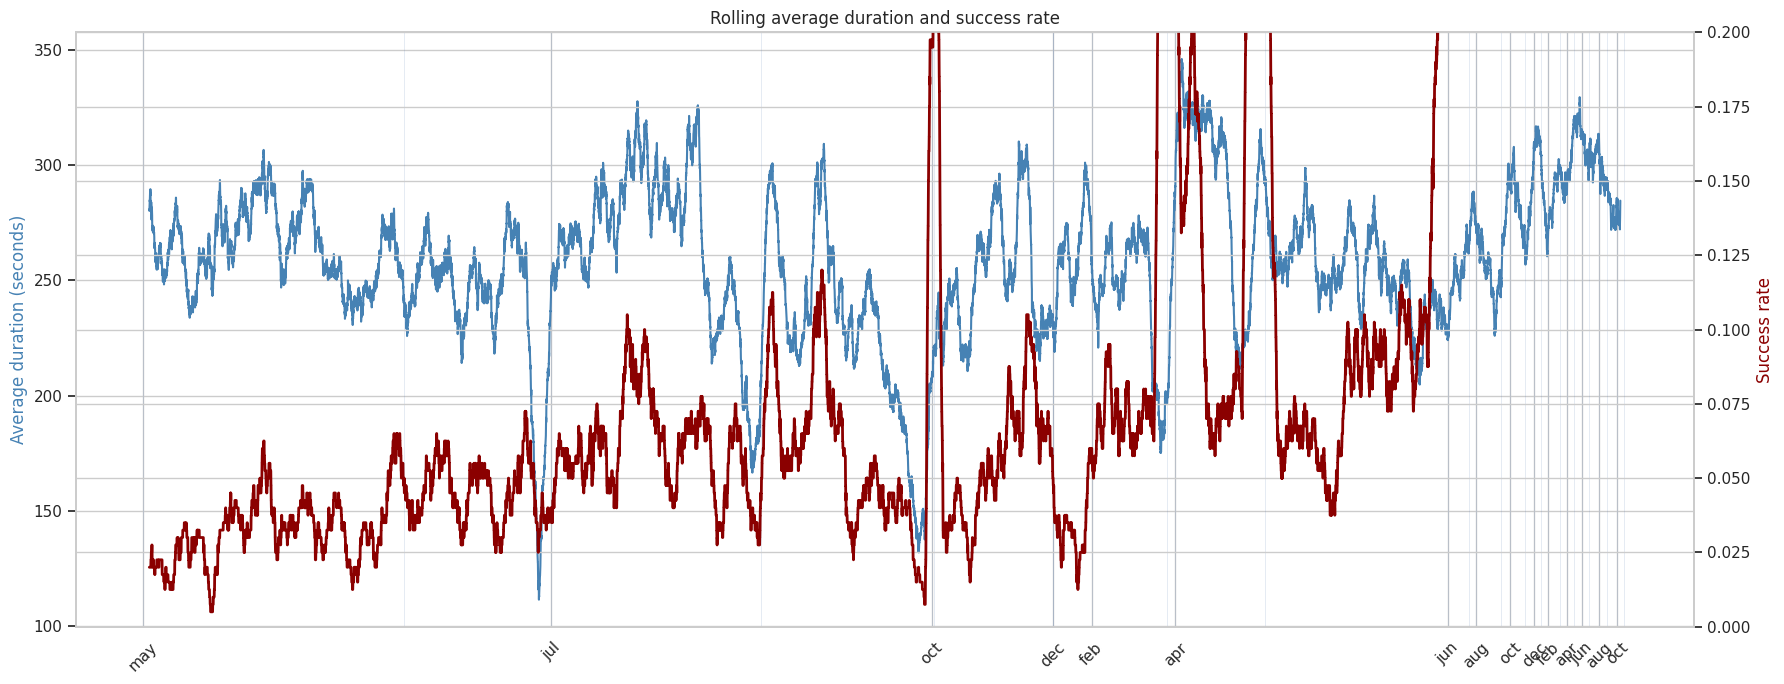

In [52]:
# @title Se periodi con chiamate più lunghe hanno avuto tasso di successo più alto
bank["rolling_duration"] = bank["duration"].rolling(window=400, center=True).mean()
bank["rolling_success"] = bank["y_numeric"].rolling(window=400, center=True).mean()

fig, ax1 = plt.subplots(figsize=(18,7))

# Duration
ax1.plot(bank.index, bank["rolling_duration"],
         color="steelblue", linewidth=1.5, label="Duration")
ax1.set_ylabel("Average duration (seconds)", color="steelblue")

# Success rate
ax2 = ax1.twinx()
ax2.plot(bank.index, bank["rolling_success"],
         color="darkred", linewidth=2, label="Success rate")
ax2.set_ylabel("Success rate", color="darkred")
ax2.set_ylim(0, 0.2)    # adjust depending on your data

month_starts = bank.groupby("month_index").head(1).index
month_labels = bank.loc[month_starts, "month"]

for x in month_starts:
    ax1.axvline(x=x, linewidth=0.5, alpha=0.2)

ax1.set_xticks(month_starts[::2])
ax1.set_xticklabels(month_labels[::2], rotation=45)

plt.title("Rolling average duration and success rate")
plt.tight_layout()
plt.show()

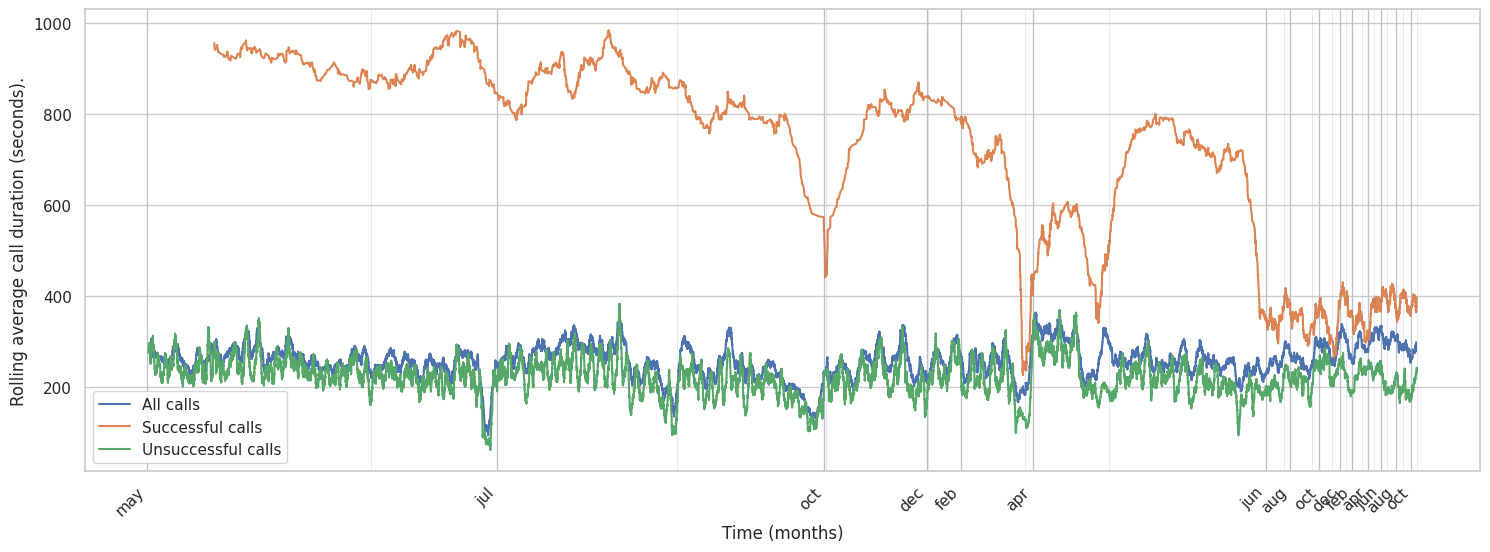

In [60]:

success = bank[bank["y_numeric"] == 1]
failure = bank[bank["y_numeric"] == 0]

plt.figure(figsize=(18,6))

plt.plot(bank["duration"].rolling(250, center=True).mean(),
         label="All calls")

plt.plot(success["duration"].rolling(100, center=True).mean(),
         label="Successful calls")

plt.plot(failure["duration"].rolling(100, center=True).mean(),
         label="Unsuccessful calls")

month_starts = bank.groupby("month_index").head(1).index
month_labels = bank.loc[month_starts, "month"].astype(str)

for x in month_starts:
    plt.axvline(x=x, linewidth=0.5, alpha=0.2)
# Display every second month label to reduce clutter
plt.xticks(month_starts[::2], month_labels[::2], rotation=45, ha='right') # Use month names and rotate labels

#plt.axhline(y=bank["duration"].mean(), color='red', linestyle='--', alpha=0.5) non ci sta molto

plt.ylabel("Rolling average call duration (seconds).")
plt.xlabel("Time (months)")
plt.legend()

Il grafico evidenzia che le chiamate che portano alla sottoscrizione del conto deposito sono mediamente più lunghe di quelle non di successo per tutto il periodo di osservazione. La durata media delle chiamate a esito positivo mostra inoltre una maggiore variabilità temporale, tendendo a decrescere verso la fine della campagna.
Le chiamate con esito negativo mantengono una durata più stabile ma su livelli nettamente inferiori.

La durata media si colloca tra i due andamenti, ma più vicina alle chiamate con esito negativo, che rappresentano difatti la maggioranza dei contatti.

Non so se ce ne facciamo qualcosa :(

In [39]:
success_rate_by_month_index = bank.groupby('month_index')['y_numeric'].mean().sort_values(ascending=False)
success_rate_by_month_index.head(5)

,y_numeric
month_index,
5,0.612500
23,0.588785
24,0.572650
22,0.561644
26,0.542208


In [62]:
# Create a mapping from month_index to month name
month_index_to_name = bank[['month_index', 'month']].drop_duplicates().set_index('month_index')['month']

# Convert the success_rate_by_month_index Series to a DataFrame for easier merging
success_rate_df = success_rate_by_month_index.reset_index()
success_rate_df.columns = ['month_index', 'success_rate']

# Merge with the month names and sort by success rate
success_rate_with_names = success_rate_df.merge(month_index_to_name.rename('month'), left_on='month_index', right_index=True)
success_rate_with_names = success_rate_with_names.sort_values(by='success_rate', ascending=False)

success_rate_with_names.head(30)

,month_index,success_rate,month
0,5,0.612500,oct
1,23,0.588785,apr
2,24,0.572650,may
3,22,0.561644,mar
4,26,0.542208,jul
5,21,0.526912,feb
6,27,0.523077,aug
7,18,0.494949,nov
8,19,0.492537,dec
9,28,0.491582,sep


# Fase 3

# Conclusioni